# ISIC 2024 - CNN on the Images

A pretrained ResNet18 trained on the lesion images, using the same 5 patient folds as LightGBM so the out-of-fold
predictions can be blended later. I developed it locally on my laptop GPU (RTX 4050) first.

1. Look at the images
2. Dataset and transforms
3. Model
4. Train one fold first to check the speed and the score
5. All 5 folds -> out-of-fold predictions
6. Save `oof_cnn.csv`

In [1]:
import io
import sys
import time

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
from einops import rearrange
from sklearn.metrics import roc_auc_score

sys.path.insert(0, '../src')
from isic_pauc import p_auc_tpr

DATA_DIR = '../data'
IMG_PATH = r'C:\Users\xmuha\isic\data\train-image.hdf5'   # on C: because D: is almost full
SEED = 42
N_FOLDS = 5

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device, torch.cuda.get_device_name(0) if torch.cuda.is_available() else '')

cuda NVIDIA GeForce RTX 4050 Laptop GPU


## 1. Folds and a look at the images
`train-image.hdf5` has one entry per lesion: the key is the `isic_id` and the value is the JPEG file as bytes.

In [2]:
folds = pd.read_csv(f'{DATA_DIR}/folds.csv')   # isic_id, patient_id, target, fold
print(folds.shape)
folds['target'].value_counts()

(401059, 4)


target
0    400666
1       393
Name: count, dtype: int64

In [3]:
def load_image(h5, isic_id):
    img_bytes = h5[isic_id][()]
    img = Image.open(io.BytesIO(img_bytes))
    return img.convert('RGB')


with h5py.File(IMG_PATH, 'r') as h5:
    print(len(h5.keys()), 'images')
    sample = load_image(h5, folds['isic_id'].iloc[0])
    print(sample.size)

401059 images
(139, 139)


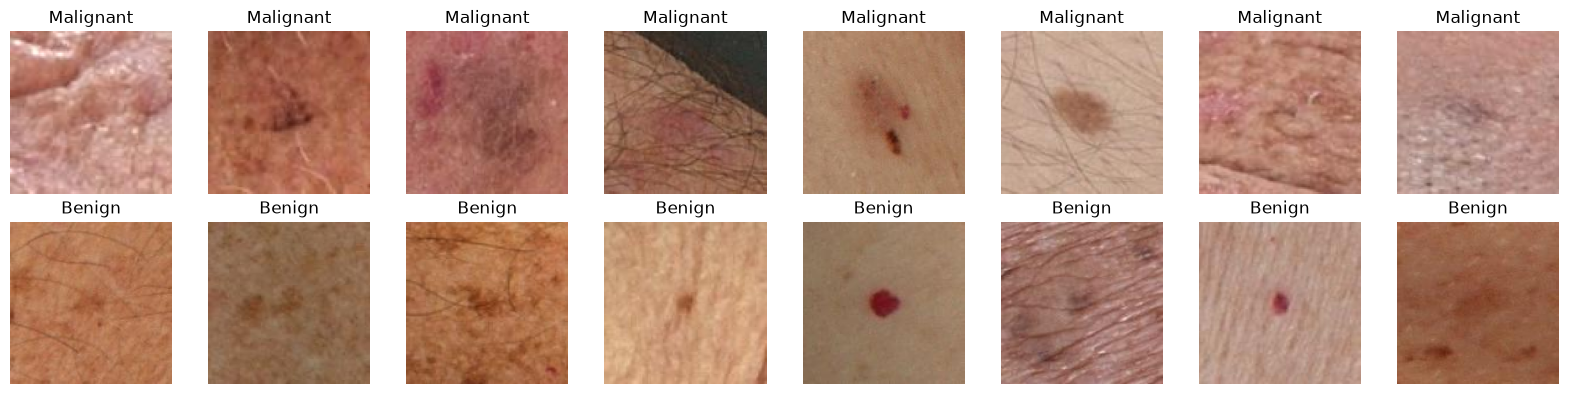

In [7]:
malignant = folds[folds['target'] == 1].sample(8, random_state=SEED)
benign = folds[folds['target'] == 0].sample(8, random_state=SEED)

with h5py.File(IMG_PATH, 'r') as h5:
    fig, axes = plt.subplots(2, 8, figsize=(16, 4))

    for i, (_, row) in enumerate(malignant.iterrows()):
        axes[0, i].imshow(load_image(h5, row['isic_id']))
        axes[0, i].axis('off')
        axes[0, i].set_title('Malignant')

    for i, (_, row) in enumerate(benign.iterrows()):
        axes[1, i].imshow(load_image(h5, row['isic_id']))
        axes[1, i].axis('off')
        axes[1, i].set_title('Benign')

    plt.tight_layout()
    plt.show()

The malignant lesions are often bigger, with uneven colors (red/pink, grey and dark brown mixed together) and
blurry borders. Most benign ones are small, faint brown spots, but some are small bright red dots, so "red" alone
doesn't mean malignant. The image quality is low, there is a lot of hair and skin texture, and some lesions are
hard to see.

## 2. Dataset and transforms
- The hdf5 file is opened in `__getitem__` the first time it's needed instead of in `__init__`, because an open h5py file can't be copied to DataLoader worker processes.
- Pretrained ImageNet models expect images normalized with the ImageNet mean and std.
- Augmentation only for training: flips and rotations (a lesion can be photographed from any angle) and a little color jitter.

In [8]:
IMG_SIZE = 128   # the crops are ~110-150 px, bigger doesn't add information

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class LesionDataset(Dataset):
    def __init__(self, df, img_path, tfms):
        self.ids = df['isic_id'].to_numpy()
        self.targets = df['target'].to_numpy().astype('float32')
        self.img_path = img_path
        self.tfms = tfms
        self.h5 = None

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        if self.h5 is None:
            self.h5 = h5py.File(self.img_path, 'r')
        transformed_image = self.tfms(load_image(self.h5, self.ids[i]))
        return transformed_image, self.targets[i]

In [9]:
# quick check: one batch
ds = LesionDataset(folds.head(64), IMG_PATH, train_tfms)
x, y = next(iter(DataLoader(ds, batch_size=16)))
print(x.shape, y[:5])

torch.Size([16, 3, 128, 128]) tensor([0., 0., 0., 0., 0.])


## 3. Model
ResNet18 pretrained on ImageNet, with the last layer replaced by a layer with 1 output (the malignant logit). The loss is `BCEWithLogitsLoss`, which applies the sigmoid inside the loss and is more stable than a separate sigmoid + `BCELoss`, especially with mixed precision.

In [10]:
def make_model():
    model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model.to(device)


model = make_model()
print(sum(p.numel() for p in model.parameters()) / 1e6, 'M parameters')

11.177025 M parameters


## 4. Train and predict functions
- Training set: all malignant lesions + a random sample of benign ones (20 benign per malignant), the same idea as the downsampling for LightGBM.
- Validation: the full fold (about 80k lesions), so the pAUC can be compared with LightGBM and the benchmarks.
- Mixed precision (`torch.autocast` + `GradScaler`) makes training faster on the GPU and uses less memory.

In [14]:
BATCH_SIZE = 64
EPOCHS = 5
LR = 1e-4
NEG_PER_POS = 20
NUM_WORKERS = 0   # 0 is the safest on Windows, try 2-4 later if loading is slow


def sample_train(trn, fold):
    pos = trn[trn['target'] == 1]
    neg = trn[trn['target'] == 0].sample(
        n=len(pos) * NEG_PER_POS,
        random_state=SEED + fold
    )
    return pd.concat([pos, neg])


def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        with torch.autocast(device_type='cuda', dtype=torch.float16):
            logits = rearrange(model(x), 'b 1 -> b')
            loss = criterion(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total += loss.item() * len(x)
    return total / len(loader.dataset)


@torch.no_grad()
def predict(model, loader):
    # no autocast here: in float16 the logits are rounded to ~3 digits and a lot of lesions got exactly the same score
    model.eval()
    preds = []
    for x, _ in loader:
        x = x.to(device)
        logits = rearrange(model(x), 'b 1 -> b')
        p = torch.sigmoid(logits).cpu().numpy()
        preds.append(p)
    return np.concatenate(preds)

In [15]:
def run_fold(fold, epochs=EPOCHS):
    trn = folds[folds['fold'] != fold]
    val = folds[folds['fold'] == fold]
    trn_s = sample_train(trn, fold)

    train_loader = DataLoader(LesionDataset(trn_s, IMG_PATH, train_tfms), batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(LesionDataset(val, IMG_PATH, val_tfms), batch_size=256,
                            shuffle=False, num_workers=NUM_WORKERS)

    torch.manual_seed(SEED + fold)
    model = make_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    criterion = nn.BCEWithLogitsLoss()
    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(epochs):
        t0 = time.time()
        loss = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        print(f'fold {fold} epoch {epoch}: train loss {loss:.4f} ({time.time() - t0:.0f}s)')

    pred = predict(model, val_loader)
    pauc = p_auc_tpr(val['target'], pred, 0.80)
    auc = roc_auc_score(val['target'], pred)
    print(f'fold {fold}: pAUC={pauc:.4f}  AUC={auc:.4f}')
    return model, pred, pauc, auc

## 5. One fold first
Checking the speed and the score on fold 0 before running all 5.

In [16]:
model0, pred0, pauc0, auc0 = run_fold(0)

fold 0 epoch 0: train loss 0.2359 (25s)
fold 0 epoch 1: train loss 0.1309 (25s)
fold 0 epoch 2: train loss 0.1196 (25s)
fold 0 epoch 3: train loss 0.1110 (25s)
fold 0 epoch 4: train loss 0.1073 (29s)
fold 0: pAUC=0.1495  AUC=0.9325


## 6. All 5 folds -> out-of-fold predictions

In [18]:
oof_cnn = np.zeros(len(folds))
cnn_paucs, cnn_aucs = [], []

for fold in range(N_FOLDS):
    model, pred, pauc, auc = run_fold(fold)
    val_idx = folds.index[folds['fold'] == fold]
    oof_cnn[val_idx] = pred

    cnn_paucs.append(pauc)
    cnn_aucs.append(auc)
    torch.save(model.state_dict(), f'C:/Users/xmuha/isic/cnn_fold{fold}.pt')

print(f'CNN  pAUC: {np.mean(cnn_paucs):.4f} +/- {np.std(cnn_paucs):.4f}   AUC: {np.mean(cnn_aucs):.4f} +/- {np.std(cnn_aucs):.4f}')

fold 0 epoch 0: train loss 0.2359 (26s)
fold 0 epoch 1: train loss 0.1309 (25s)
fold 0 epoch 2: train loss 0.1196 (25s)
fold 0 epoch 3: train loss 0.1110 (37s)
fold 0 epoch 4: train loss 0.1073 (37s)
fold 0: pAUC=0.1495  AUC=0.9325
fold 1 epoch 0: train loss 0.1779 (27s)
fold 1 epoch 1: train loss 0.1291 (26s)
fold 1 epoch 2: train loss 0.1167 (26s)
fold 1 epoch 3: train loss 0.1091 (26s)
fold 1 epoch 4: train loss 0.0997 (27s)
fold 1: pAUC=0.1584  AUC=0.9438
fold 2 epoch 0: train loss 0.3528 (29s)
fold 2 epoch 1: train loss 0.1415 (29s)
fold 2 epoch 2: train loss 0.1266 (29s)
fold 2 epoch 3: train loss 0.1130 (29s)
fold 2 epoch 4: train loss 0.1080 (29s)
fold 2: pAUC=0.1517  AUC=0.9347
fold 3 epoch 0: train loss 0.2831 (35s)
fold 3 epoch 1: train loss 0.1280 (37s)
fold 3 epoch 2: train loss 0.1144 (36s)
fold 3 epoch 3: train loss 0.1079 (35s)
fold 3 epoch 4: train loss 0.0951 (35s)
fold 3: pAUC=0.1339  AUC=0.9094
fold 4 epoch 0: train loss 0.2667 (36s)
fold 4 epoch 1: train loss 0.127

## 6b. Fixing the float16 ties
The first version of `predict` ran inside `autocast`, so the model's output (the logits) was in float16, which
only has about 3 significant digits. Most lesions have a score close to 0, and a lot of them ended up with exactly
the same score: only about 4,000 different values out of ~80,000 per fold. Tied lesions can't be ranked against
each other, which loses information for the pAUC. `predict` now runs in float32 (no `autocast`). The models don't
need to be trained again, I load the saved fold models and only predict again.

In [7]:
oof_cnn = np.zeros(len(folds))
cnn_paucs, cnn_aucs = [], []

for fold in range(N_FOLDS):
    val = folds[folds['fold'] == fold]
    val_loader = DataLoader(LesionDataset(val, IMG_PATH, val_tfms), batch_size=256,
                            shuffle=False, num_workers=NUM_WORKERS)

    model = make_model()
    model.load_state_dict(torch.load(f'C:/Users/xmuha/isic/cnn_fold{fold}.pt', map_location=device))

    pred = predict(model, val_loader)
    oof_cnn[(folds['fold'] == fold).to_numpy()] = pred

    pauc = p_auc_tpr(val['target'], pred, 0.80)
    auc = roc_auc_score(val['target'], pred)
    cnn_paucs.append(pauc)
    cnn_aucs.append(auc)
    print(f'fold {fold}: pAUC={pauc:.4f}  AUC={auc:.4f}  unique scores: {len(np.unique(pred))} of {len(pred)}')

print(f'CNN  pAUC: {np.mean(cnn_paucs):.4f} +/- {np.std(cnn_paucs):.4f}   AUC: {np.mean(cnn_aucs):.4f} +/- {np.std(cnn_aucs):.4f}')

fold 0: pAUC=0.1496  AUC=0.9325  unique scores: 79886 of 80211


fold 1: pAUC=0.1586  AUC=0.9438  unique scores: 80011 of 80211


fold 2: pAUC=0.1516  AUC=0.9347  unique scores: 79817 of 80216


fold 3: pAUC=0.1350  AUC=0.9094  unique scores: 79682 of 80211


fold 4: pAUC=0.1212  AUC=0.8843  unique scores: 79877 of 80210
CNN  pAUC: 0.1432 +/- 0.0134   AUC: 0.9209 +/- 0.0216


## 7. Save out-of-fold predictions

In [8]:
oof_cnn_df = folds[['isic_id', 'patient_id', 'target', 'fold']].copy()
oof_cnn_df['oof_cnn'] = oof_cnn

oof_cnn_df.to_csv(
    '../data/oof_cnn.csv',
    index=False
)

pd.read_csv('../data/oof_cnn.csv').head()

,isic_id,patient_id,target,fold,oof_cnn
0,ISIC_0015670,IP_1235828,0,1,0.011834
1,ISIC_0015845,IP_8170065,0,4,0.005450
2,ISIC_0015864,IP_6724798,0,4,0.006334
3,ISIC_0015902,IP_4111386,0,1,0.005295
4,ISIC_0024200,IP_8313778,0,1,0.002395
